In [1]:
# Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Import DataSet

data = pd.read_csv("data.csv", low_memory=False)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

In [3]:
# Clean rows with Na from the following list of columns

important_columns = ["Price", "District", "City", "Town", "Type", "EnergyCertificate", "TotalArea", "Parking", "Elevator", "LivingArea", "NumberOfBathrooms"]
data_clean = data.dropna(subset=important_columns)

data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102105 entries, 0 to 135534
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  102105 non-null  float64
 1   District               102105 non-null  object 
 2   City                   102105 non-null  object 
 3   Town                   102105 non-null  object 
 4   Type                   102105 non-null  object 
 5   EnergyCertificate      102105 non-null  object 
 6   GrossArea              25269 non-null   float64
 7   TotalArea              102105 non-null  float64
 8   Parking                102105 non-null  float64
 9   HasParking             51481 non-null   object 
 10  Floor                  26363 non-null   object 
 11  ConstructionYear       81308 non-null   float64
 12  EnergyEfficiencyLevel  50624 non-null   object 
 13  PublishDate            22418 non-null   object 
 14  Garage                 50624 non-null   o

In [4]:
# Visualize each unique column value

object_columns = data_clean.select_dtypes(include=["object"])

for column in object_columns.columns:
    unique_vals = data_clean[column].unique()
    print(unique_vals)
    print("\n")

['Vila Real' 'Faro' 'Leiria' 'Porto' 'Lisboa' 'Guarda' 'Viseu' 'Coimbra'
 'Castelo Branco' 'Setúbal' 'Santarém' 'Évora' 'Braga'
 'Ilha de São Miguel' 'Bragança' 'Beja' 'Aveiro' 'Ilha de Porto Santo'
 'Portalegre' 'Ilha de Santa Maria' 'Ilha Terceira' 'Viana do Castelo'
 'Ilha da Madeira' 'Z - Fora de Portugal' 'Ilha do Faial'
 'Ilha das Flores']


['Valpaços' 'São Brás de Alportel' 'Albufeira' 'Portimão' 'Loulé'
 'Vila do Bispo' 'Olhão' 'Faro' 'Lagos' 'Peniche'
 'Vila Real de Santo António' 'Lagoa (Algarve)' 'Silves' 'Castro Marim'
 'Alcoutim' 'Porto' 'Aljezur' 'Tavira' 'Monchique' 'Sintra' 'Manteigas'
 'Seia' 'Tondela' 'Trancoso' 'Gouveia' 'Vila Nova de Foz Côa' 'Guarda'
 'Almeida' 'Celorico da Beira' 'Matosinhos' 'Lisboa' 'Fornos de Algodres'
 'Mêda' 'Pinhel' 'Coimbra' 'Azambuja' 'Figueira de Castelo Rodrigo'
 'Sabugal' 'Ansião' 'Sertã' 'Aguiar da Beira' 'Marinha Grande' 'Seixal'
 'Miranda do Corvo' 'Soure' 'Montemor-o-Velho' 'Penela' 'Figueira da Foz'
 'Oliveira do Hospital' 'Pampil

In [5]:
# Drop the following columns 
drop_columns = ["EnergyEfficiencyLevel", "HasParking"]
data_clean = data_clean.drop(columns=drop_columns, errors='ignore').copy()

# Filter 'House' and 'Apartment' properties
data_clean = data_clean[data_clean['Type'].isin(['House', 'Apartment'])].copy()

# Filter properties from 'Porto' district
data_clean = data_clean[data_clean['District'] == 'Porto'].copy()

# Change "City" and "Town" to "Municipality" and "Parish"
rename_dict = {"City": "Municipality", "Town": "Parish"}
data_clean = data_clean.rename(columns=rename_dict)

# Fill missing data with average
numerical_cols = data_clean.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    mean_value = data_clean[col].mean()
    data_clean.loc[:, col] = data_clean[col].fillna(mean_value)

# Remove extreme value outliers from dataframe
continuous_features = ["Price", "TotalArea", "LivingArea"]
for col in continuous_features:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]

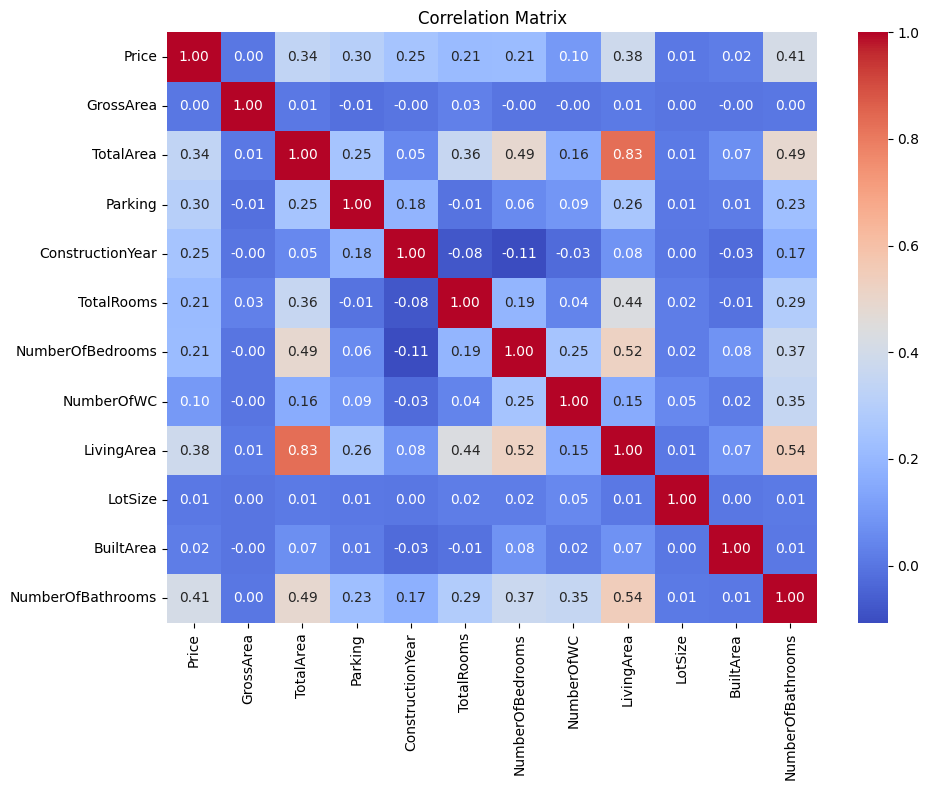

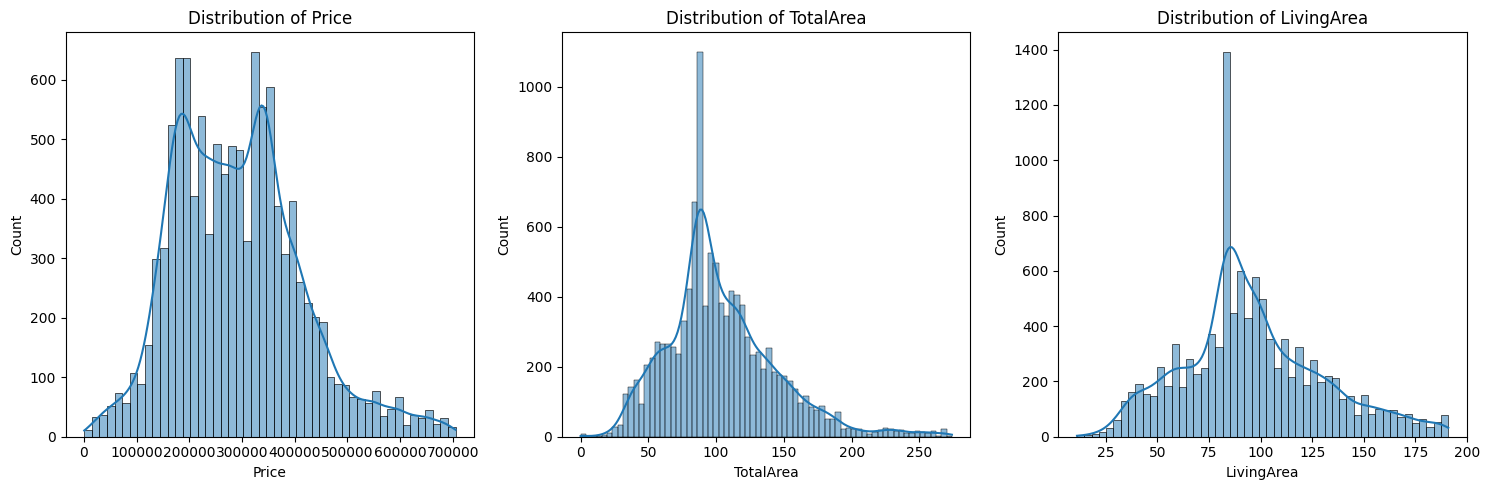

In [6]:
# Create informative graphs for each column before moving to the machine model 
data_copy = data_clean.copy()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
numerical_df = data_copy.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

# Distribution of continuous features
plt.figure(figsize=(15, 5))
for i, col in enumerate(["Price", "TotalArea", "LivingArea"]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data_copy[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()
plt.close()


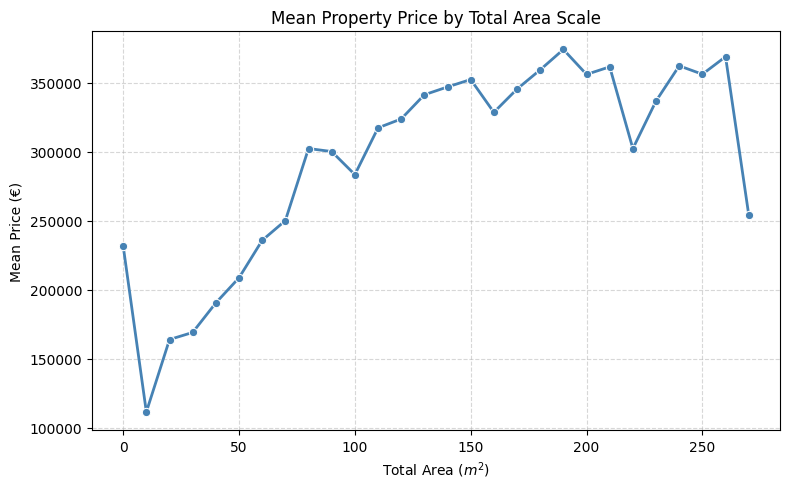

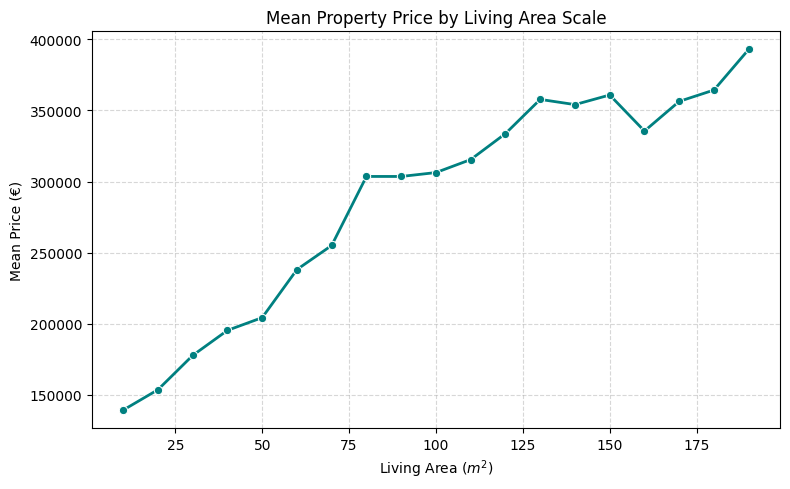

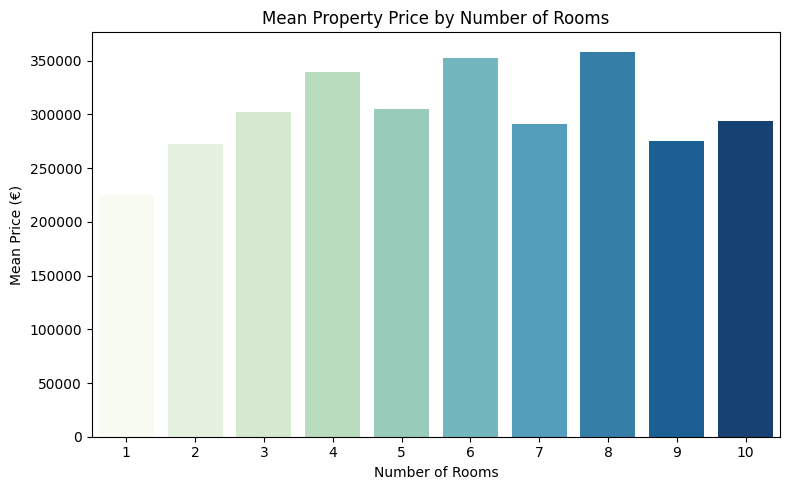

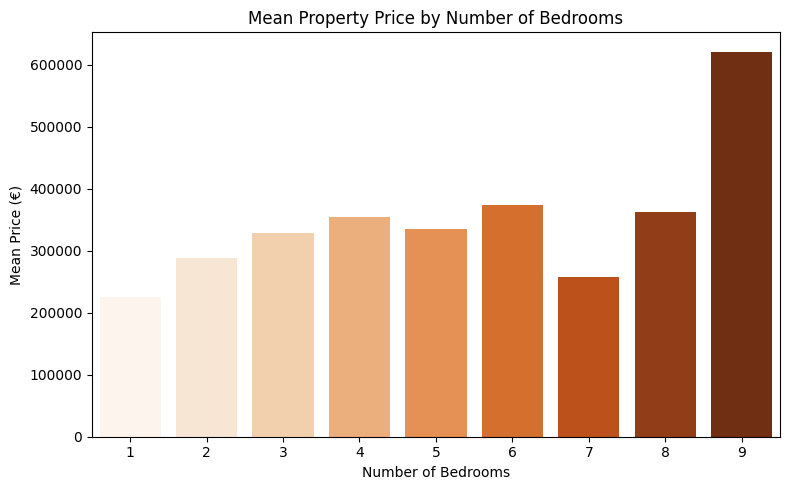

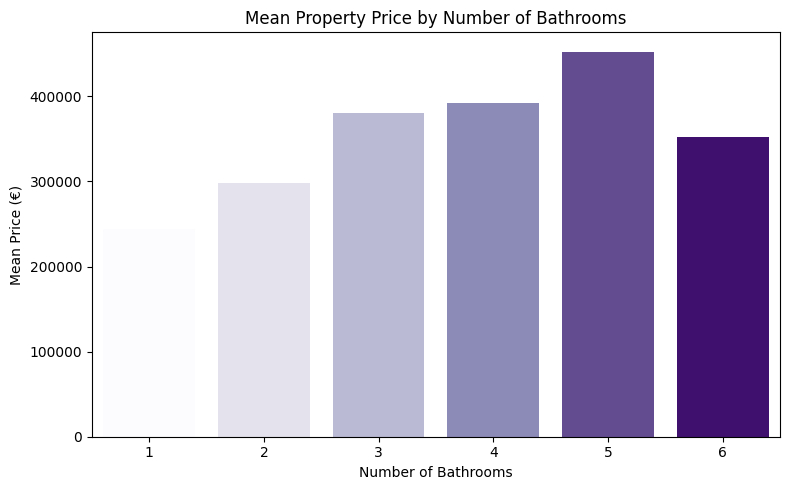

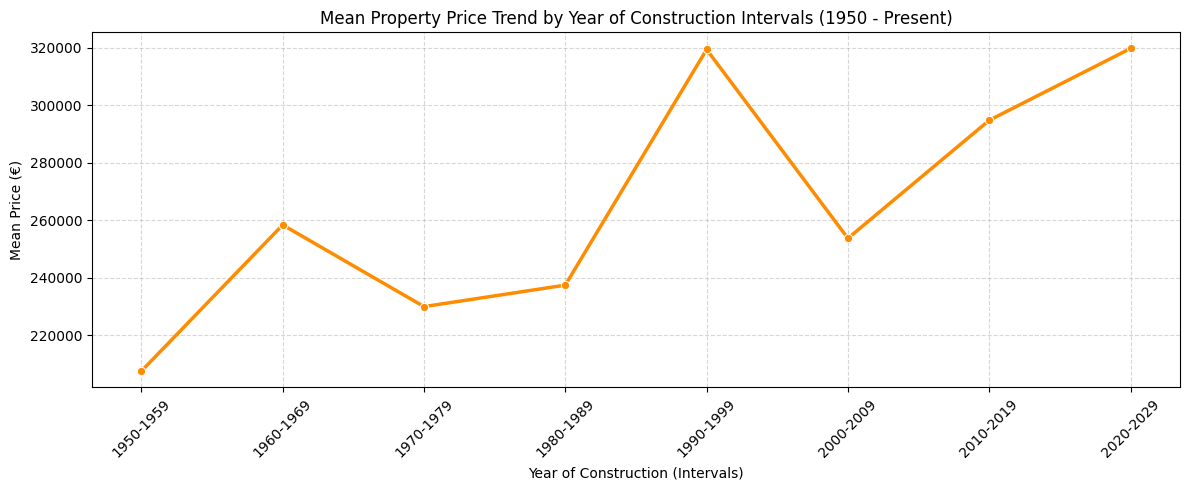

In [7]:
data_copy = data_clean.copy()

# Mean Price of estate to Total Area 
plt.figure(figsize=(8, 5))
data_copy['TotalArea_Group'] = (data_copy['TotalArea'] // 10) * 10
total_trend = data_copy.groupby('TotalArea_Group')['Price'].mean().reset_index()

sns.lineplot(data=total_trend, x='TotalArea_Group', y='Price', marker='o', color='steelblue', linewidth=2)
plt.title("Mean Property Price by Total Area Scale")
plt.xlabel("Total Area ($m^2$)")
plt.ylabel("Mean Price (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()

# Mean Price of estate to Living Area
plt.figure(figsize=(8, 5))
data_copy['LivingArea_Group'] = (data_copy['LivingArea'] // 10) * 10
living_trend = data_copy.groupby('LivingArea_Group')['Price'].mean().reset_index()

sns.lineplot(data=living_trend, x='LivingArea_Group', y='Price', marker='o', color='teal', linewidth=2)
plt.title("Mean Property Price by Living Area Scale")
plt.xlabel("Living Area ($m^2$)")
plt.ylabel("Mean Price (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()

# Mean Price of estate to Number of Rooms
plt.figure(figsize=(8, 5))
room_data = data_copy.dropna(subset=['TotalRooms']).copy()
room_data['TotalRooms'] = room_data['TotalRooms'].astype(int)
room_filter = room_data[room_data['TotalRooms'].between(1, 10)]
room_mean = room_filter.groupby('TotalRooms')['Price'].mean().reset_index()

sns.barplot(data=room_mean, x='TotalRooms', y='Price', hue='TotalRooms', palette='GnBu', legend=False)
plt.title("Mean Property Price by Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Mean Price (€)")
plt.tight_layout()
plt.show()
plt.close()

# Mean Price of estate to Number of Bedrooms
plt.figure(figsize=(8, 5))
bedroom_data = data_copy.dropna(subset=['NumberOfBedrooms']).copy()
bedroom_data['NumberOfBedrooms'] = bedroom_data['NumberOfBedrooms'].astype(int)
bedroom_filter = bedroom_data[bedroom_data['NumberOfBedrooms'].between(1, 10)]
bedroom_mean = bedroom_filter.groupby('NumberOfBedrooms')['Price'].mean().reset_index()

sns.barplot(data=bedroom_mean, x='NumberOfBedrooms', y='Price', hue='NumberOfBedrooms', palette='Oranges', legend=False)
plt.title("Mean Property Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Mean Price (€)")
plt.tight_layout()
plt.show()
plt.close()

# Mean Price of estate to Number of Bathrooms
plt.figure(figsize=(8, 5))
bath_data = data_copy.dropna(subset=['NumberOfBathrooms']).copy()
bath_data['NumberOfBathrooms'] = bath_data['NumberOfBathrooms'].astype(int)
bath_filter = bath_data[bath_data['NumberOfBathrooms'].between(1, 6)]
bath_mean = bath_filter.groupby('NumberOfBathrooms')['Price'].mean().reset_index()

sns.barplot(data=bath_mean, x='NumberOfBathrooms', y='Price', hue='NumberOfBathrooms', palette='Purples', legend=False)
plt.title("Mean Property Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Mean Price (€)")
plt.tight_layout()
plt.show()
plt.close()

# Mean Price of estate to Year of Construction
plt.figure(figsize=(12, 5))
year_data = data_copy.dropna(subset=['ConstructionYear']).copy()
year_data['ConstructionYear'] = year_data['ConstructionYear'].astype(int)
valid_years = year_data[year_data['ConstructionYear'] >= 1950].copy()
valid_years['Year_Interval_Start'] = (valid_years['ConstructionYear'] // 10) * 10
valid_years['Interval_Label'] = valid_years['Year_Interval_Start'].apply(lambda x: f"{x}-{x+9}")
yearly_trend = valid_years.groupby(['Year_Interval_Start', 'Interval_Label'])['Price'].mean().reset_index()
yearly_trend = yearly_trend.sort_values('Year_Interval_Start')

sns.lineplot(
    data=yearly_trend, 
    x='Interval_Label', 
    y='Price', 
    marker='o', 
    color='darkorange', 
    linewidth=2.5,
    sort=False
)
plt.title("Mean Property Price Trend by Year of Construction Intervals (1950 - Present)")
plt.xlabel("Year of Construction (Intervals)")
plt.ylabel("Mean Price (€)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()

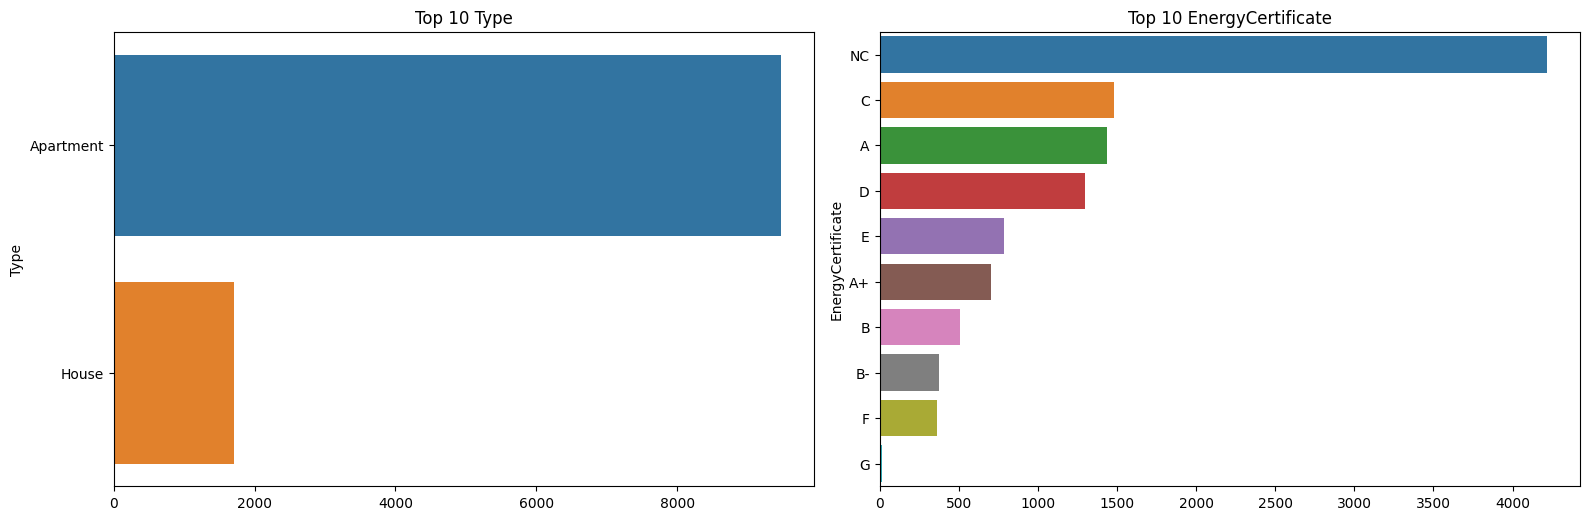

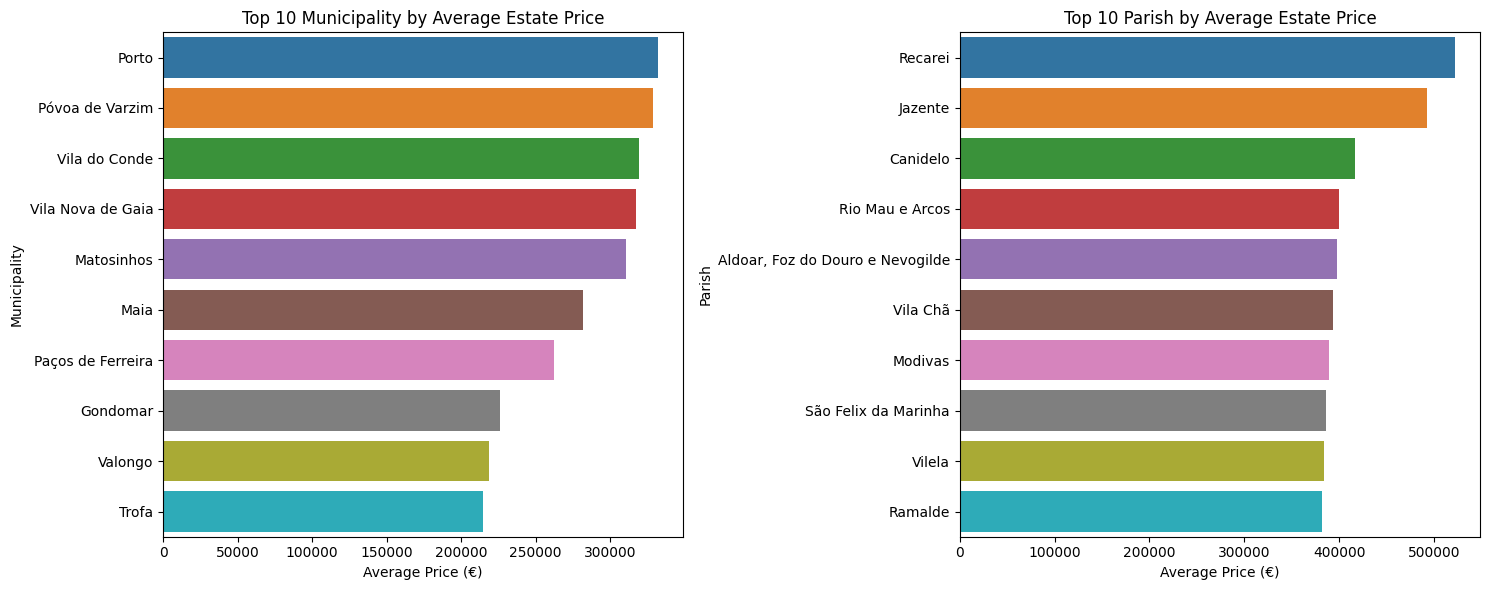

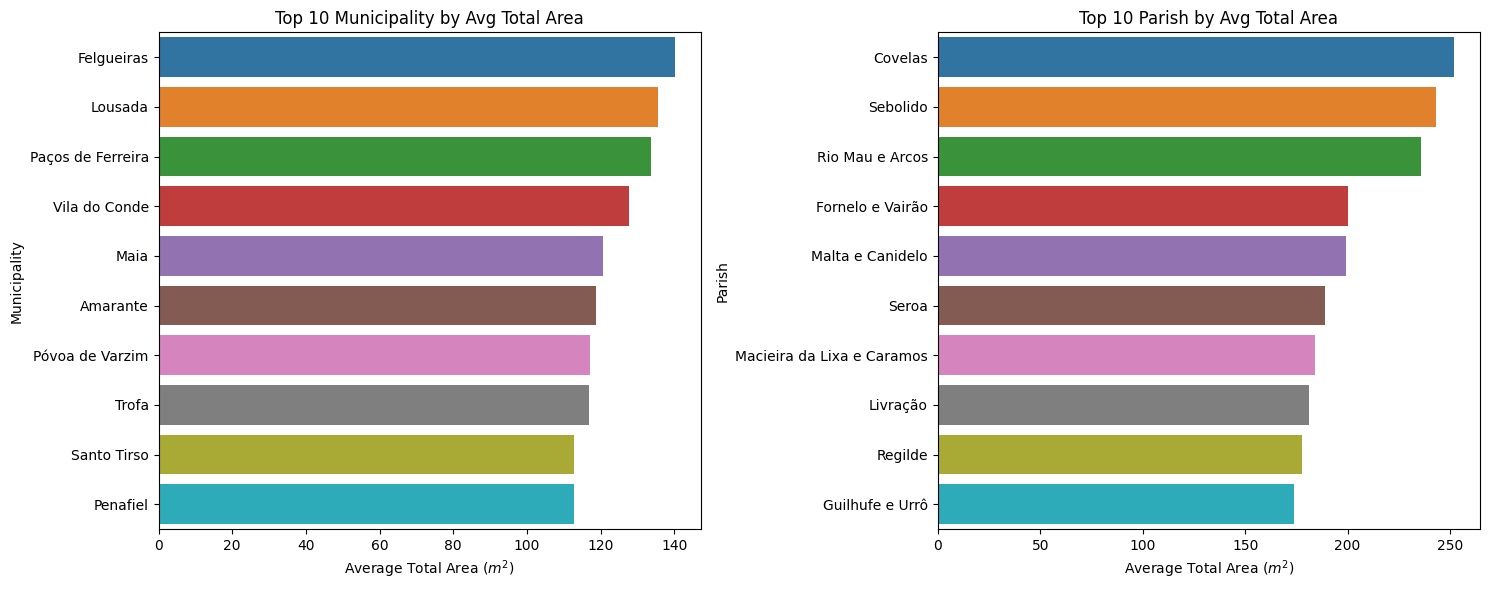

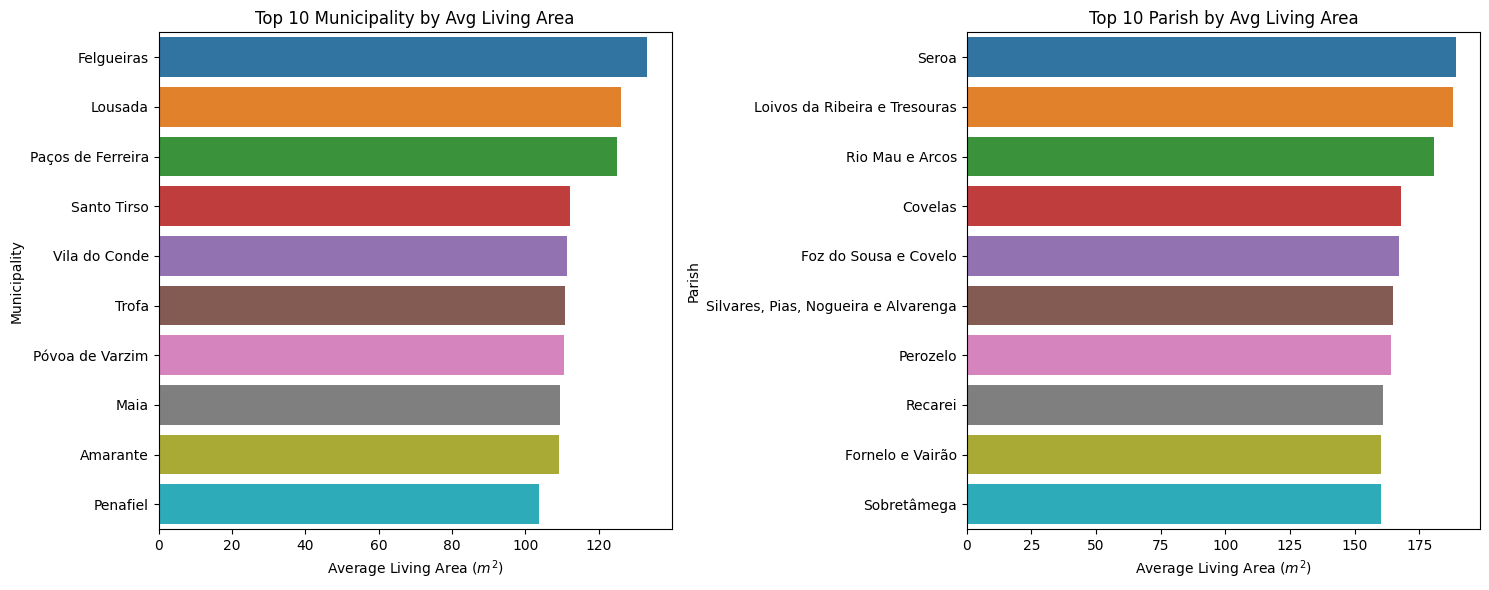

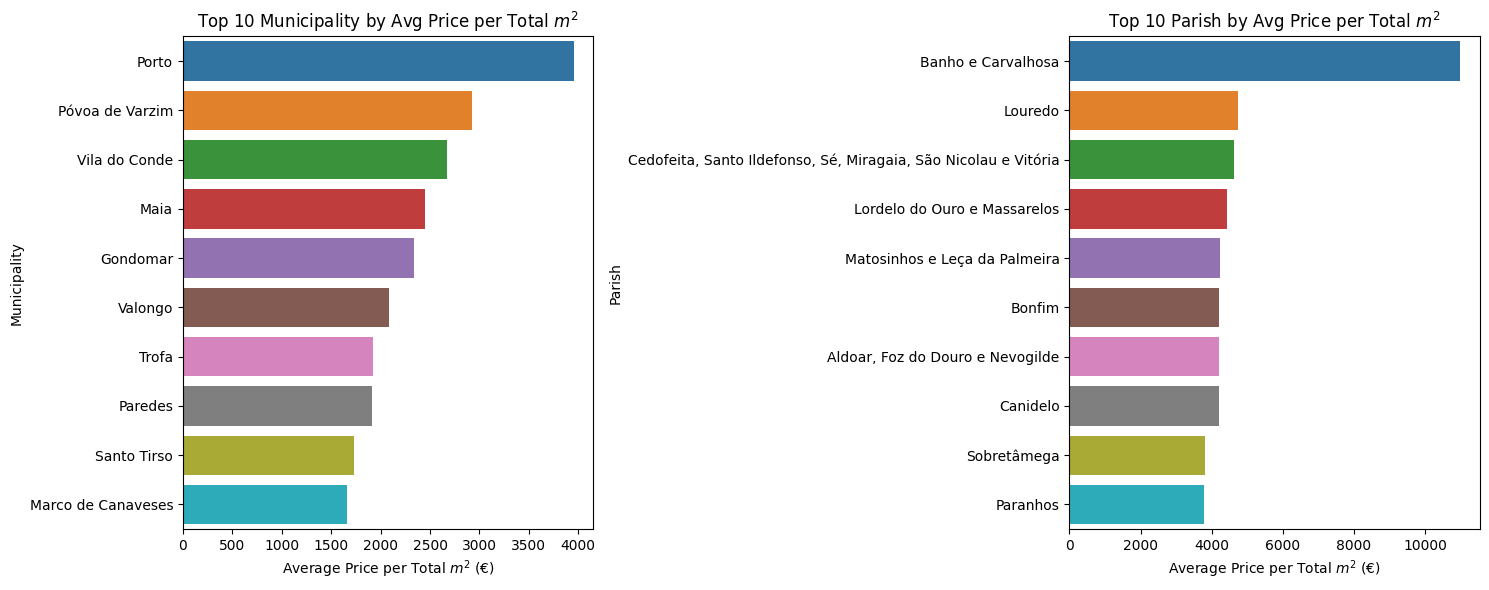

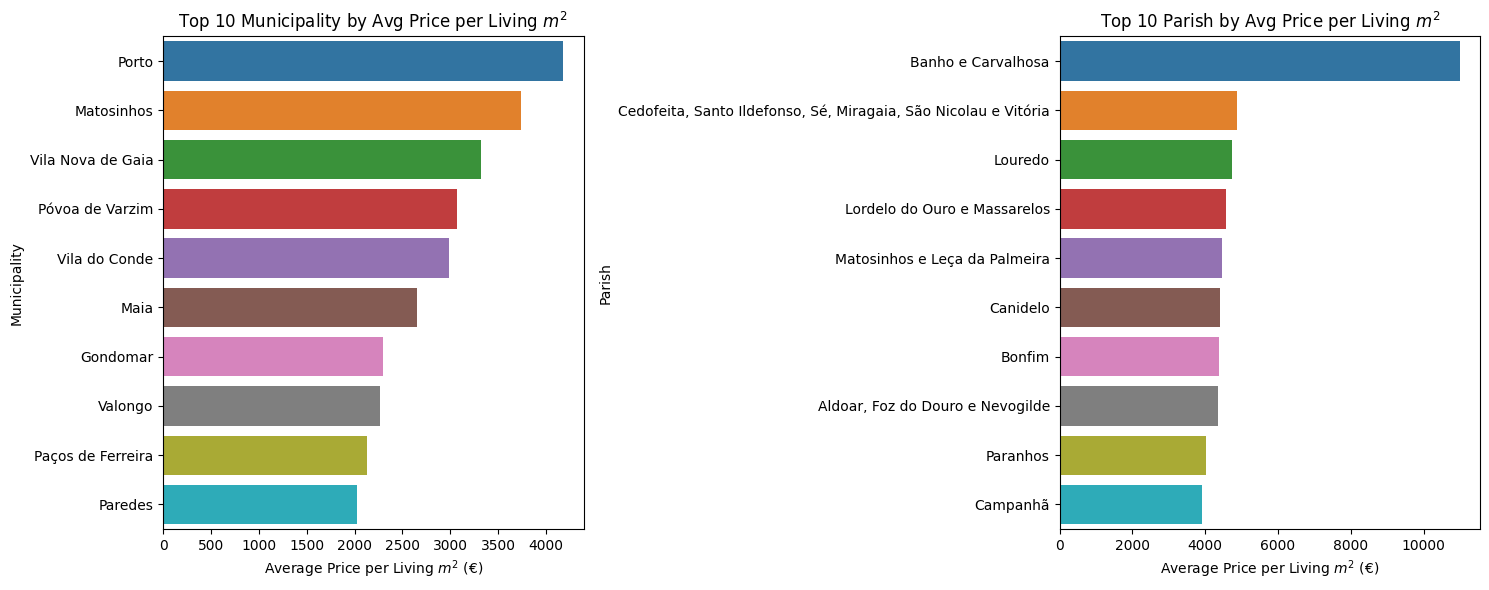

In [8]:
# Distribution of core categorical features (Top 10 categories)
data_copy = data_clean.copy()

categorical_features = ["Type", "EnergyCertificate"]
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    top_cats = data_copy[col].value_counts().iloc[:10]
    sns.barplot(x=top_cats.values, y=top_cats.index, hue=top_cats.index, legend=False)
    plt.title(f"Top 10 {col}")
plt.tight_layout()
plt.show()
plt.close()

# Top 10 Municipalities and Parishes by Average Estate Price
geo_features = ["Municipality", "Parish"]
plt.figure(figsize=(15, 6))
for i, col in enumerate(geo_features):
    plt.subplot(1, 2, i + 1)
    top_price_cats = (data_copy.groupby(col)['Price']
                        .mean()
                        .replace([np.inf, -np.inf], np.nan)
                        .dropna()
                        .sort_values(ascending=False)
                        .head(10))
    sns.barplot(x=top_price_cats.values, y=top_price_cats.index, hue=top_price_cats.index, legend=False)
    plt.title(f"Top 10 {col} by Average Estate Price")
    plt.xlabel("Average Price (€)")
plt.tight_layout()
plt.show()
plt.close()

# Top 10 Municipalities and Parishes by Average Square meter of Total Area
geo_features = ["Municipality", "Parish"]
plt.figure(figsize=(15, 6))
for i, col in enumerate(geo_features):
    plt.subplot(1, 2, i + 1)
    top_area_cats = (data_copy.groupby(col)['TotalArea']
                        .mean()
                        .replace([np.inf, -np.inf], np.nan)
                        .dropna()
                        .sort_values(ascending=False)
                        .head(10))
    sns.barplot(x=top_area_cats.values, y=top_area_cats.index, hue=top_area_cats.index, legend=False)
    plt.title(f"Top 10 {col} by Avg Total Area")
    plt.xlabel("Average Total Area ($m^2$)")
plt.tight_layout()
plt.show()
plt.close()

# Top 10 Municipalities and Parishes by Average Square meter of Living Area
geo_features = ["Municipality", "Parish"]
plt.figure(figsize=(15, 6))
for i, col in enumerate(geo_features):
    plt.subplot(1, 2, i + 1)
    top_area_cats = (data_copy.groupby(col)['LivingArea']
                        .mean()
                        .replace([np.inf, -np.inf], np.nan)
                        .dropna()
                        .sort_values(ascending=False)
                        .head(10))
    sns.barplot(x=top_area_cats.values, y=top_area_cats.index, hue=top_area_cats.index, legend=False)
    plt.title(f"Top 10 {col} by Avg Living Area")
    plt.xlabel("Average Living Area ($m^2$)")
plt.tight_layout()
plt.show()
plt.close()

# Top 10 Municipalities and Parishes by Average Square meter of Total area Estate Price
data_copy['Price_per_TotalArea'] = data_copy['Price'] / data_copy['TotalArea']
geo_features = ["Municipality", "Parish"]
plt.figure(figsize=(15, 6))
for i, col in enumerate(geo_features):
    if col in data_copy.columns:
        plt.subplot(1, 2, i + 1)
        top_sm_price_cats = (data_copy.groupby(col)['Price_per_TotalArea']
                                .mean()
                                .replace([np.inf, -np.inf], np.nan)
                                .dropna()
                                .sort_values(ascending=False)
                                .head(10))
        sns.barplot(x=top_sm_price_cats.values, y=top_sm_price_cats.index, hue=top_sm_price_cats.index, legend=False)
        plt.title(f"Top 10 {col} by Avg Price per Total $m^2$")
        plt.xlabel("Average Price per Total $m^2$ (€)")
plt.tight_layout()
plt.show()
plt.close()

# Top 10 Municipalities and Parishes by Average Square meter of Living area Estate Price
data_copy['Price_per_LivingArea'] = data_copy['Price'] / data_copy['LivingArea']
geo_features = ["Municipality", "Parish"]
plt.figure(figsize=(15, 6))
for i, col in enumerate(geo_features):
    if col in data_copy.columns:
        plt.subplot(1, 2, i + 1)
        top_sm_price_cats = (data_copy.groupby(col)['Price_per_LivingArea']
                                .mean()
                                .replace([np.inf, -np.inf], np.nan)
                                .dropna()
                                .sort_values(ascending=False)
                                .head(10))
        sns.barplot(x=top_sm_price_cats.values, y=top_sm_price_cats.index, hue=top_sm_price_cats.index, legend=False)
        plt.title(f"Top 10 {col} by Avg Price per Living $m^2$")
        plt.xlabel("Average Price per Living $m^2$ (€)")
plt.tight_layout()
plt.show()
plt.close()

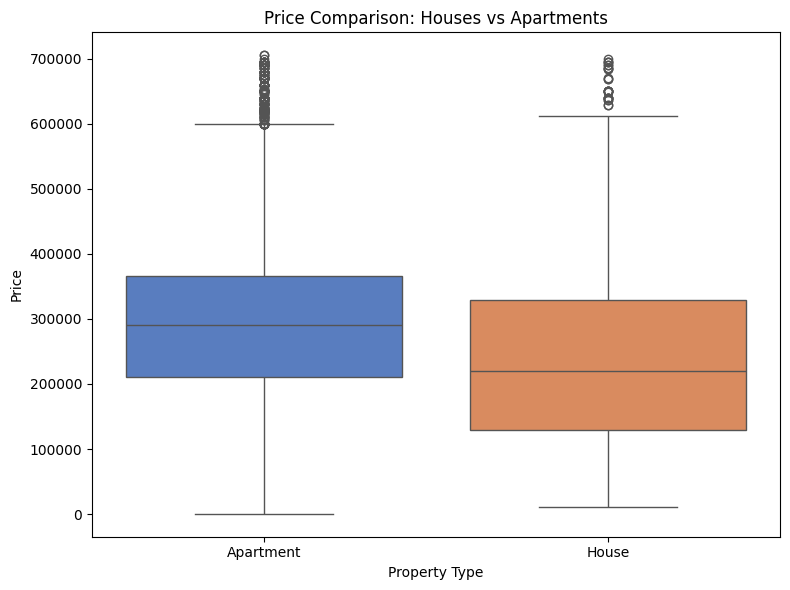

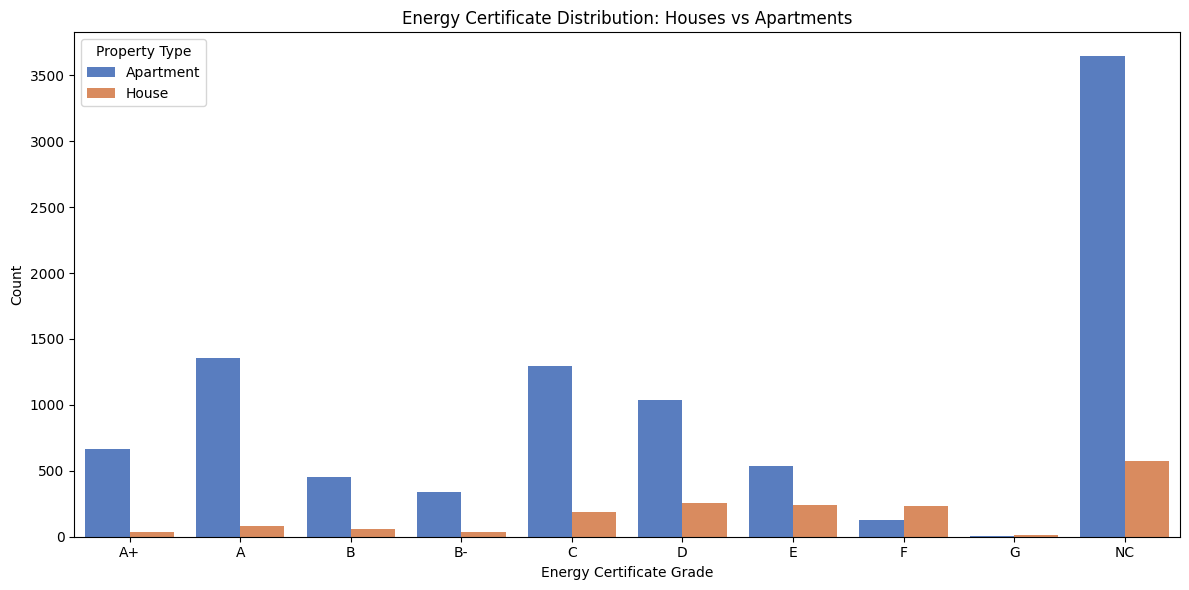

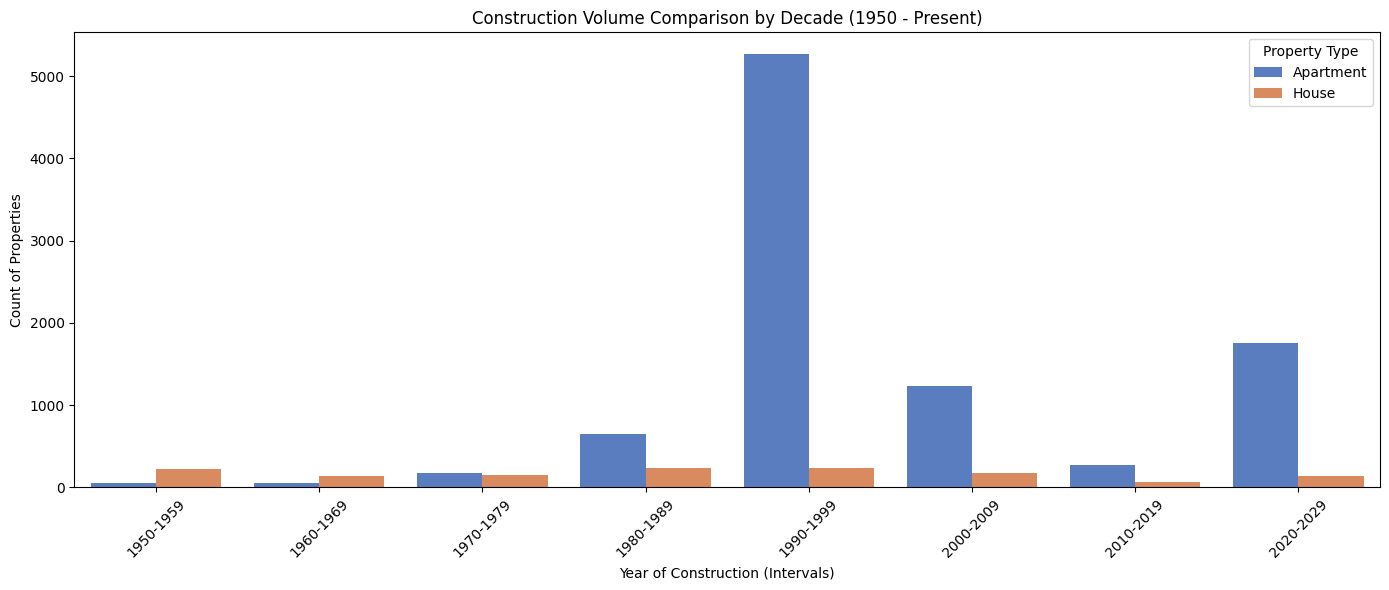

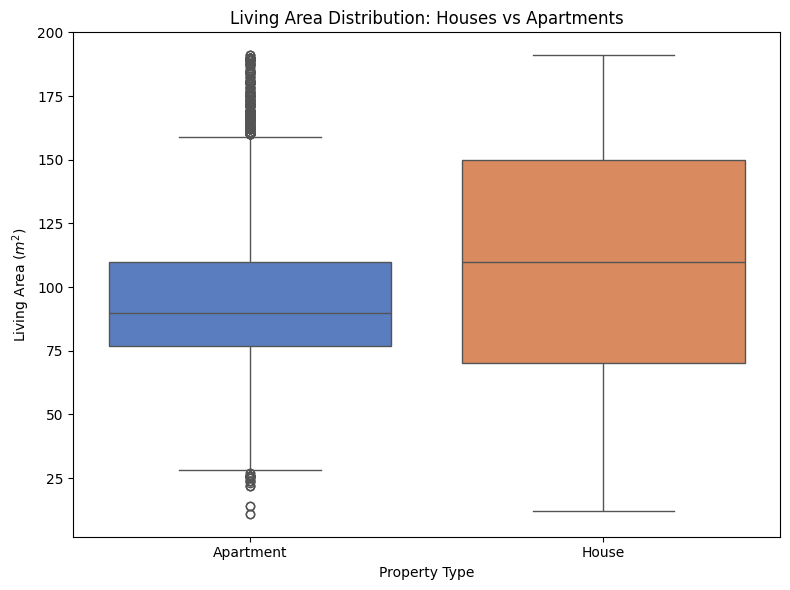

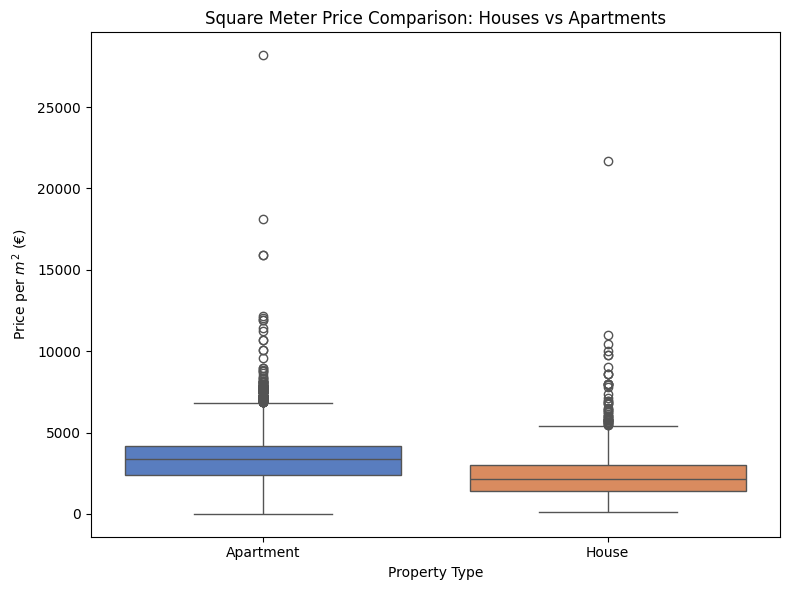

In [9]:
# Compare House prices vs Apartment prices
data_copy = data_clean.copy()

house_apt_data = data_copy[data_copy['Type'].isin(['House', 'Apartment'])]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=house_apt_data, 
    x='Type', 
    y='Price', 
    hue='Type', 
    palette='muted', 
    legend=False
)
plt.title("Price Comparison: Houses vs Apartments")
plt.xlabel("Property Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()
plt.close()

# Compare Energy Certificate of Houses vs Apartments
plt.figure(figsize=(12, 6))
house_apt_data = data_copy[data_copy['Type'].isin(['House', 'Apartment'])]
cert_order = ['A+', 'A', 'B', 'B-', 'C', 'D', 'E', 'F', 'G', 'NC']
available_order = [c for c in cert_order if c in house_apt_data['EnergyCertificate'].unique()]

sns.countplot(
    data=house_apt_data,
    x='EnergyCertificate',
    hue='Type',
    palette='muted',
    order=available_order
)
plt.title("Energy Certificate Distribution: Houses vs Apartments")
plt.xlabel("Energy Certificate Grade")
plt.ylabel("Count")
plt.legend(title="Property Type")
plt.tight_layout()
plt.show()
plt.close()

# Compare Year of Construction of Houses vs Apartments
plt.figure(figsize=(14, 6))
year_data = data_copy[data_copy['Type'].isin(['House', 'Apartment'])].dropna(subset=['ConstructionYear']).copy()
year_data['ConstructionYear'] = year_data['ConstructionYear'].astype(int)
valid_years = year_data[year_data['ConstructionYear'] >= 1950].copy()
valid_years['Year_Interval_Start'] = (valid_years['ConstructionYear'] // 10) * 10
valid_years['Interval_Label'] = valid_years['Year_Interval_Start'].apply(lambda x: f"{x}-{x+9}")
valid_years = valid_years.sort_values('Year_Interval_Start')

sns.countplot(
    data=valid_years,
    x='Interval_Label',
    hue='Type',
    palette='muted'
)
plt.title("Construction Volume Comparison by Decade (1950 - Present)")
plt.xlabel("Year of Construction (Intervals)")
plt.ylabel("Count of Properties")
plt.xticks(rotation=45)
plt.legend(title="Property Type")
plt.tight_layout()
plt.show()
plt.close()

# Compare Living Area of Houses vs Apartments
plt.figure(figsize=(8, 6))
house_apt_data = data_copy[data_copy['Type'].isin(['House', 'Apartment'])]

sns.boxplot(
    data=house_apt_data, 
    x='Type', 
    y='LivingArea', 
    hue='Type', 
    palette='muted', 
    legend=False
)
plt.title("Living Area Distribution: Houses vs Apartments")
plt.xlabel("Property Type")
plt.ylabel("Living Area ($m^2$)")
plt.tight_layout()
plt.show()
plt.close()

# Compare Square meter price of Houses vs Apartments
plt.figure(figsize=(8, 6))
house_apt_data = data_copy[data_copy['Type'].isin(['House', 'Apartment'])].copy()
house_apt_data['Price_per_m2'] = house_apt_data['Price'] / house_apt_data['LivingArea']

sns.boxplot(
    data=house_apt_data, 
    x='Type', 
    y='Price_per_m2', 
    hue='Type', 
    palette='muted', 
    legend=False
)
plt.title("Square Meter Price Comparison: Houses vs Apartments")
plt.xlabel("Property Type")
plt.ylabel("Price per $m^2$ (€)")
plt.tight_layout()
plt.show()
plt.close()

In [10]:
# Machine Learning using Linear Regression 
data_ml = data_clean.copy()

target = "Price"

numerical_features = [
    "GrossArea", "TotalArea", "ConstructionYear", "TotalRooms", 
    "NumberOfBedrooms", "NumberOfWC", "LivingArea", "LotSize", 
    "BuiltArea", "NumberOfBathrooms"
]

categorical_features = [
    "District", "Municipality", "Parish", "Type", "EnergyCertificate", 
    "Parking", "Floor", "PublishDate", "Garage", "Elevator", 
    "ElectricCarsCharging", "ConservationStatus"
]

data_ml = data_ml[[target] + (numerical_features + categorical_features)].copy()

data_preprocessed = pd.get_dummies(data_ml, columns=categorical_features, drop_first=True)

In [11]:
# Divide dataframe into two parts: Training and Testing (20/80)

X = data_preprocessed.drop(columns=[target])
Y = data_preprocessed[target]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)

print(f"Training set size: {X_train.shape[0]} properties")
print(f"Testing set size: {X_test.shape[0]} properties")

Training set size: 8947 properties
Testing set size: 2237 properties


In [12]:
# Train model with Linear Regression

model_linear = LinearRegression()
model_linear.fit(X_train, Y_train)
print("Model training complete!")
print(f"\n")

# Test Model with Linear Regression

Y_pred = model_linear.predict(X_test)

mae_linear = mean_absolute_error(Y_test, Y_pred)
mse_linear = mean_squared_error(Y_test, Y_pred)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(Y_test, Y_pred)

print("--- Evaluation Results ---")
print(f"R^2 Score: {r2_linear:.4f}")
print(f"Mean Absolute Error (MAE): €{mae_linear:,.2f}")
print(f"Root Mean Squared Error (RMSE): €{rmse_linear:,.2f}")

Model training complete!


--- Evaluation Results ---
R^2 Score: 0.6991
Mean Absolute Error (MAE): €46,474.11
Root Mean Squared Error (RMSE): €66,397.58


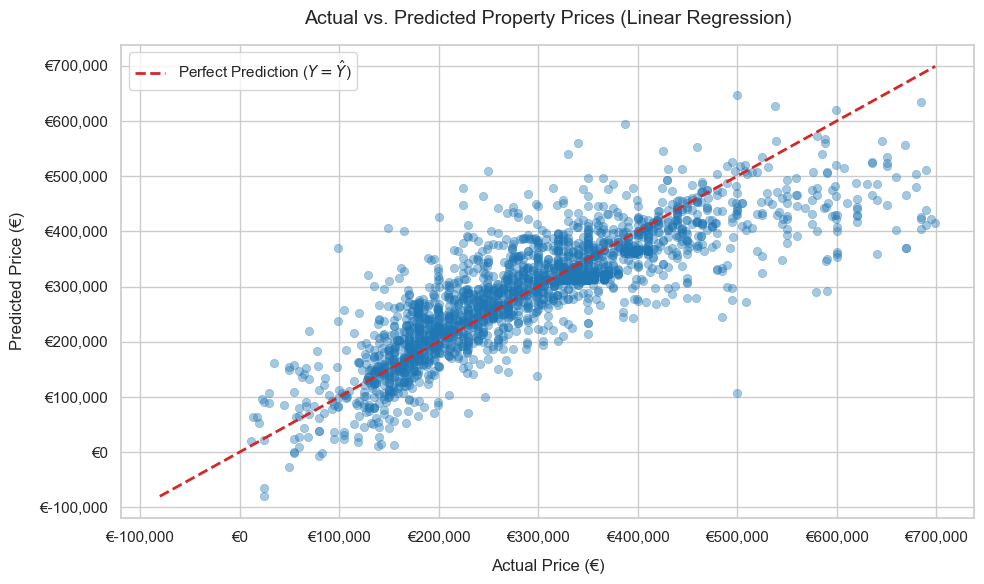

In [13]:
# Real vs Prediction prices graph for Linear Regression

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=Y_test, 
    y=Y_pred, 
    alpha=0.4,
    color='#1f77b4',
    edgecolor=None
)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='#d62728',
    linestyle='--', 
    linewidth=2, 
    label=r'Perfect Prediction ($Y = \hat{Y}$)'
)

plt.title("Actual vs. Predicted Property Prices (Linear Regression)", fontsize=14, pad=15)
plt.xlabel("Actual Price (€)", fontsize=12, labelpad=10)
plt.ylabel("Predicted Price (€)", fontsize=12, labelpad=10)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{int(x):,}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{int(x):,}"))

plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Train model with Random Forest

model_forest = RandomForestRegressor(n_estimators=200, max_depth=50, random_state=50, n_jobs=-1)
model_forest.fit(X_train, Y_train)
print("Model training complete!")
print(f"\n")

# Test Model with Random Forest

Y_pred = model_forest.predict(X_test)

mae_forest = mean_absolute_error(Y_test, Y_pred)
mse_forest = mean_squared_error(Y_test, Y_pred)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(Y_test, Y_pred)

print("--- Evaluation Results ---")
print(f"R^2 Score: {r2_forest:.4f}")
print(f"Mean Absolute Error (MAE): €{mae_forest:,.2f}")
print(f"Root Mean Squared Error (RMSE): €{rmse_forest:,.2f}")

Model training complete!


--- Evaluation Results ---
R^2 Score: 0.8337
Mean Absolute Error (MAE): €27,976.70
Root Mean Squared Error (RMSE): €49,358.56


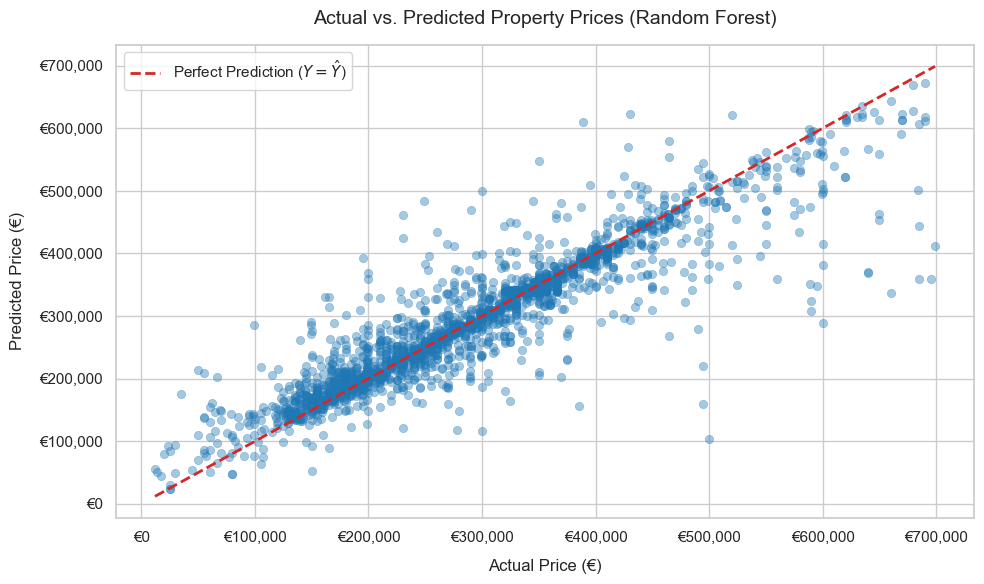

In [15]:
# Real vs Prediction prices graph for Random Forest

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=Y_test, 
    y=Y_pred, 
    alpha=0.4,
    color='#1f77b4',
    edgecolor=None
)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='#d62728',
    linestyle='--', 
    linewidth=2, 
    label=r'Perfect Prediction ($Y = \hat{Y}$)'
)

plt.title("Actual vs. Predicted Property Prices (Random Forest)", fontsize=14, pad=15)
plt.xlabel("Actual Price (€)", fontsize=12, labelpad=10)
plt.ylabel("Predicted Price (€)", fontsize=12, labelpad=10)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{int(x):,}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{int(x):,}"))

plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()
plt.close()